In [2]:
import emodeconnection as emc
import numpy as np
import matplotlib.pyplot as plt
import time


# Fixed parameters of Geometry
wavelength_fund = 450.0
w_core = 400.0  # [nm] Fixed width
h_core = 335.0  # [nm] Fixed height
dx, dy = 10.0, 10.0
doplots = False

# Sellmeier Material Definition
# Use double asterisks for power, ensure no spaces in the inner math, and verify the negative B3/C3 values are handled cleanly.
eq_o = '(1+2.8032/(1-0.015287/x**2)+0.36335/(1-0.036095/x**2)-33508000/(1+367200000/x**2))**0.5'
eq_e = '(1+0.017061/(1-0.043855/x**2)+3.1976/(1-0.022642/x**2)-57269000/(1-74226000/x**2))**0.5'
anisotropic_equation = f"[{eq_o},{eq_e},{eq_o}]"

In [3]:
# Launch EMode 
em = emc.EMode(simulation_name='example_AlN_waveguide_sweep1')

In [4]:
# Set Up Simulation
em.add_material(name='custom_AlN',                                  
                refractive_index_equation=anisotropic_equation, 
                wavelength_unit='um')
em.settings(window_width=2000,window_height=h_core+2000, boundary_condition='TM') # Using your 'TM' preference)
em.shape(name='Substrate', material='Al2O3', height=1000)
em.shape(name='core', material='custom_AlN', height=h_core, mask=w_core, etch_depth=h_core, sidewall_angle=5)
em.shape(name='TopClad', material='SiO2', height=800, shape_type='conformal')
if doplots: em.plot()


In [5]:
# Calculate Modes for FUNDAMENTAL WAVELENGTH
Nmodes_to_calculate = 2
em.settings(wavelength=wavelength_fund, x_resolution=dx, y_resolution=dy,window_width=2000,
            window_height=h_core+2000, num_modes=Nmodes_to_calculate, boundary_condition='TM') # Using your 'TM' preference)
em.FDM()                            #run the finite difference mode solver to find the modes of the structure
em.confinement(shape_list='core')   #calculate the confinement factor for each mode
em.report()                         #print information about the calculation results to command line
em.label_profile(name = 'dataset1') #store this set of results under label '0'
if doplots: em.plot()


In [6]:
## Run wavelength sweep:  FUNDAMENTAL WAVELENGTH
wav_nm = np.arange(448, 462, 2)

data = em.sweep(key = 'wavelength', values = wav_nm,
    result = ['effective_index','mode_order'])
em.save(simulation_name='example_AlN_waveguide_sweep1.eph')  # Save the simulation state to a fileem.save(simulation_name='example_AlN_waveguide_copy.eph')  # Save the simulation state to a file

'ok'

In [7]:
# Calculate Modes for SECOND HARMONIC WAVELENGTH
Nmodes_to_calculate = 35
em.settings(num_modes=Nmodes_to_calculate, wavelength=wavelength_fund/2, x_resolution=dx/2, y_resolution=dy/2, max_effective_index=2.6)
em.FDM()                            #run the finite difference mode solver to find the modes of the structure
em.confinement(shape_list='core')   #calculate the confinement factor for each mode
em.report()                         #print information about the calculation results to command line
em.label_profile(name = 'dataset2') #store this set of results under label 'dataset2'
if doplots: em.plot()


In [8]:
## Run wavelength sweep:  SECOND HARMONIC WAVELENGTH
wav2_nm = wav_nm/2
data2 = em.sweep(key = 'wavelength',                        #which parameter to sweep
                 values = wav2_nm,                          #values to sweep over
                 result = ['effective_index','mode_order']) #which results to return for each sweep step
em.save(simulation_name='example_AlN_waveguide_sweep1.eph')  # Save the simulation state to a fileem.save(simulation_name='example_AlN_waveguide_copy.eph')  # Save the simulation state to a file


'ok'

Success! Phase Match at SHG WL: 225.053 nm

--- Phase Matching Results ---
Target SHG Mode Index: 30
SHG Phase Match WL:    225.053 nm
Fundamental Match WL:  450.106 nm


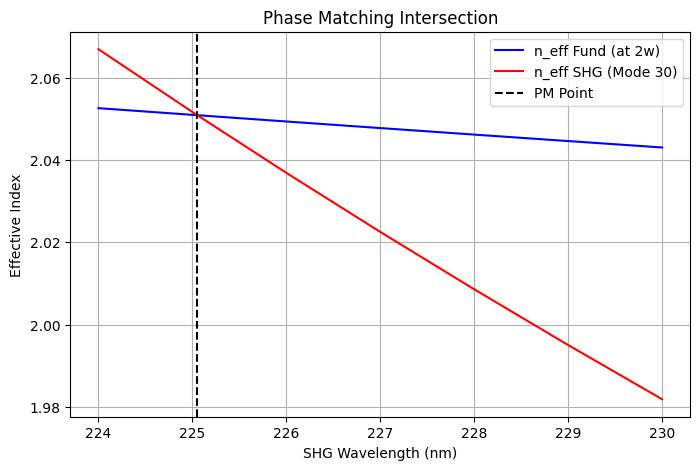

In [9]:
## --- Phase Matching Analysis ---
# 1. Extract Neff from Fundamental Sweep (Mode 0 = TM00/TE00)
neff_fund = np.array(data['effective_index'])[:, 0]

# 2. Extract Neff from SHG Sweep (Target Mode)
# Let's assume TM04 is index 30 for now; we can refine this later
target_sh_idx = 30 
neff_shg = np.array(data2['effective_index'])[:, target_sh_idx]

# 3. Calculate Delta N (We want this to be 0)
# Note: We use wav2_nm as the x-axis because it represents the SHG wavelength
delta_n = neff_fund - neff_shg

# 4. Use linear interpolation to find the exact zero-crossing
# np.interp requires the x-coordinates to be increasing. 
# Since n_eff drops with wavelength, delta_n is usually monotonic.

# Check if a crossing exists (sign change)
if np.sign(delta_n[0]) != np.sign(delta_n[-1]):
    # Note: wav2_nm must be increasing for np.interp
    pm_wl_shg = np.interp(0, delta_n, wav2_nm)
    print(f"Success! Phase Match at SHG WL: {pm_wl_shg:.3f} nm")
else:
    # If no crossing, tell us which direction to move the window
    direction = "increase" if delta_n[0] > 0 else "decrease"
    print(f"No crossing found. Try to {direction} your wavelength range.")
    pm_wl_shg = [];


print(f"\n--- Phase Matching Results ---")
print(f"Target SHG Mode Index: {target_sh_idx}")
print(f"SHG Phase Match WL:    {pm_wl_shg:.3f} nm")
print(f"Fundamental Match WL:  {pm_wl_shg * 2:.3f} nm")

# 5. Quick Plot to verify the crossing
plt.figure(figsize=(8, 5))
plt.plot(wav2_nm, neff_fund, 'b-', label='n_eff Fund (at 2w)')
plt.plot(wav2_nm, neff_shg, 'r-', label=f'n_eff SHG (Mode {target_sh_idx})')
plt.axvline(pm_wl_shg, color='k', linestyle='--', label='PM Point')
plt.xlabel('SHG Wavelength (nm)')
plt.ylabel('Effective Index')
plt.title('Phase Matching Intersection')
plt.legend()
plt.grid(True)
plt.show()


--- Processing Width: 395.0 nm ---


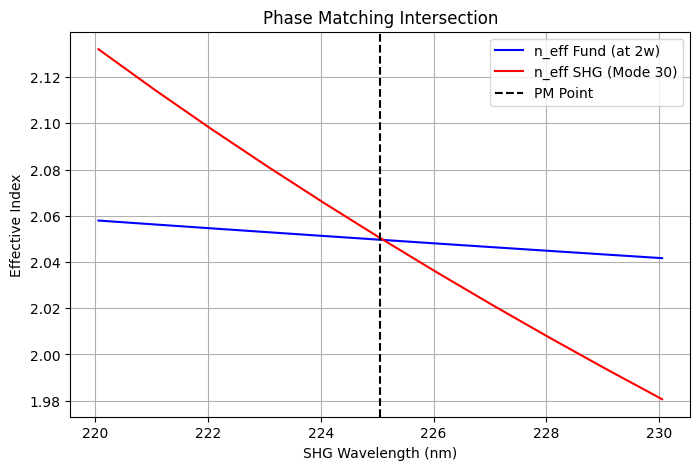

Found PM at 225.107 nm

--- Processing Width: 400.0 nm ---


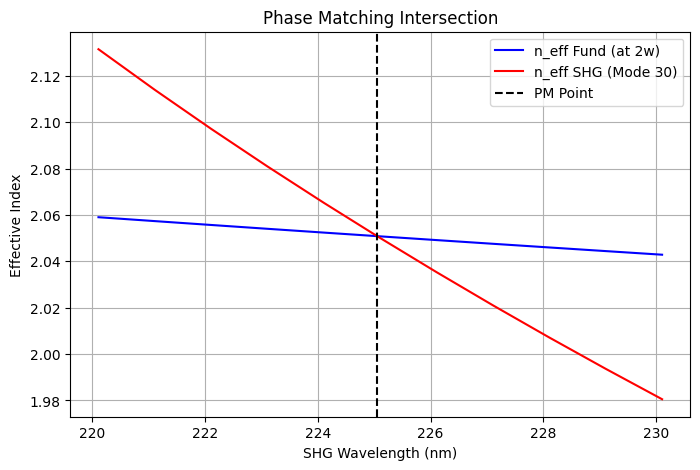

Found PM at 225.053 nm

--- Processing Width: 405.0 nm ---


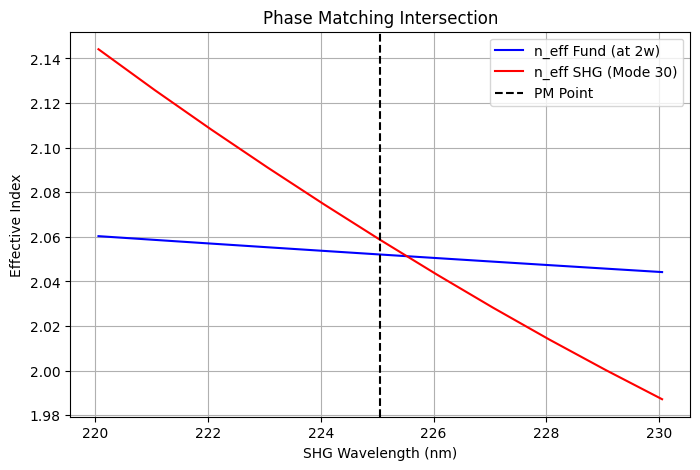

Found PM at 225.525 nm


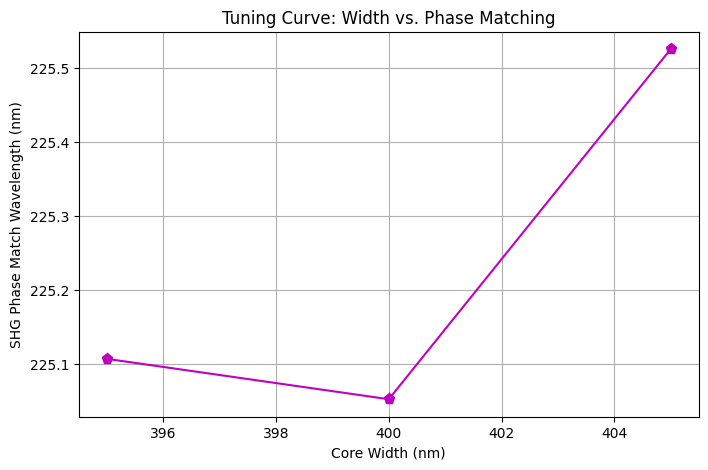

In [13]:
## --- 2D Design Loop: Width Sweep ---
widths = np.arange(w_core-5, w_core+6, 5)# Sweep width from 340nm to 460nm
pm_results = []
target_sh_idx = 30  # Start with your known TM04 index

# Define a narrow sweep range (e.g., +/- 5nm around a center)
# You can update this 'center' based on the previous result to track the PM point
current_pm_center = pm_wl_shg 

for w in widths:
    print(f"\n--- Processing Width: {w} nm ---")
    
    # 1. Update Geometry
    em.shape(name='core', material='custom_AlN', height=h_core, mask=w, 
             etch_depth=h_core, sidewall_angle=5)
    
    # 2. Define narrow wavelength windows for speed
    wav2_nm = np.linspace(current_pm_center - 5, current_pm_center + 5, 11)
    wav_fund = wav2_nm * 2
    
    # 3. Run Fundamental Sweep
    em.settings(wavelength=wav_fund[0], num_modes=2,  x_resolution=dx, y_resolution=dy)
    data = em.sweep(key='wavelength', values=wav_fund, result=['effective_index'])
    neff_fund = np.array(data['effective_index'])[:, 0]
    
    # 4. Run SHG Sweep
    em.settings(wavelength=wav2_nm[0], num_modes=35, x_resolution=dx/2, y_resolution=dy/2, max_effective_index=2.6)
    data2 = em.sweep(key='wavelength', values=wav2_nm, result=['effective_index'])
    neff_shg = np.array(data2['effective_index'])[:, target_sh_idx]
    
    # 5.
    plt.figure(figsize=(8, 5))
    plt.plot(wav2_nm, neff_fund, 'b-', label='n_eff Fund (at 2w)')
    plt.plot(wav2_nm, neff_shg, 'r-', label=f'n_eff SHG (Mode {target_sh_idx})')
    plt.axvline(pm_wl_shg, color='k', linestyle='--', label='PM Point')
    plt.xlabel('SHG Wavelength (nm)')
    plt.ylabel('Effective Index')
    plt.title('Phase Matching Intersection')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 6. Find Intersection (Your combined logic)
    delta_n = neff_fund - neff_shg
    if np.sign(delta_n[0]) != np.sign(delta_n[-1]):
        res_wl = np.interp(0, delta_n, wav2_nm)
        pm_results.append(res_wl)
        current_pm_center = res_wl  # Update center for next width iteration
        print(f"Found PM at {res_wl:.3f} nm")
    else:
        print("Warning: Phase match moved outside current wavelength window.")
        pm_results.append(np.nan)

## --- Final Plot of the Tuning Curve ---
plt.figure(figsize=(8, 5))
plt.plot(widths, pm_results, 'm-p', markersize=8, label='PM Wavelength')
plt.xlabel('Core Width (nm)')
plt.ylabel('SHG Phase Match Wavelength (nm)')
plt.title('Tuning Curve: Width vs. Phase Matching')
plt.grid(True)
plt.show()

In [14]:
widths = np.arange(w_core-5, w_core+6, 5)
print(widths)

[395. 400. 405.]


In [15]:
em.close()